In [1]:
!pip install segmentation-models-pytorch torch torchmetrics albumentations

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 7.9 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=ae152fe2fec718f09e6da536057dec93575d412c4c1f46280e4803a80522be6e
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60944 sha256=fb8d5bfad16e136e6b7c5c8f9a2dc3be99072f59e7fad8a7e66b43d2e1ab866a
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c60142835bfc889f9a482e4a67e0b817032d9c6883b64
Successfully built efficientnet-pytorch pretrainedmodels


In [2]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torchmetrics.classification import BinaryJaccardIndex, BinaryAccuracy
from torchmetrics import Dice

import segmentation_models_pytorch as smp

In [3]:
# Dataset paths
C_image_path = "/kaggle/input/pulmonary-chest-xray-abnormalities/ChinaSet_AllFiles/ChinaSet_AllFiles/CXR_png/"
C_masks_path = "/kaggle/input/shcxr-lung-mask/mask/"

# Output directories
BASE_OUTPUT_DIR = "/kaggle/working/segmentation"
TRAIN_IMAGE_DIR = os.path.join(BASE_OUTPUT_DIR, "train_images")
TRAIN_MASK_DIR  = os.path.join(BASE_OUTPUT_DIR, "train_masks")
TEST_IMAGE_DIR  = os.path.join(BASE_OUTPUT_DIR, "test_images")
TEST_MASK_DIR   = os.path.join(BASE_OUTPUT_DIR, "test_masks")

for d in [TRAIN_IMAGE_DIR, TRAIN_MASK_DIR, TEST_IMAGE_DIR, TEST_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

In [4]:
# List and sort image files
image_files = sorted([f for f in os.listdir(C_image_path) if f.endswith('.png')])
print("Number of Shenzhen images:", len(image_files))
# Full paths for image files
image_files_full = [os.path.join(C_image_path, f) for f in image_files]

Number of Shenzhen images: 662


In [5]:
# Shuffle and split 80% train, 20% test.
random.shuffle(image_files_full)
split_index = int(len(image_files_full) * 0.8)
train_files = image_files_full[:split_index]
test_files  = image_files_full[split_index:]

print("Number of training images:", len(train_files))
print("Number of test images:", len(test_files))

Number of training images: 529
Number of test images: 133


In [6]:
# Process each image (read, resize, binarize)

IMG_SIZE = (512, 512)
skipped = 0

for img_file in image_files_full:
    base_file = os.path.basename(img_file)
    # Determine corresponding mask filename.
    if "_mask" not in base_file:
        filename, ext = os.path.splitext(base_file)
        mask_filename = f"{filename}_mask{ext}"
    else:
        mask_filename = base_file
    mask_file = os.path.join(C_masks_path, mask_filename)
    
    image = cv2.imread(img_file)
    mask  = cv2.imread(mask_file, cv2.IMREAD_GRAYSCALE)
    
    if image is None or mask is None:
        skipped += 1
        continue
    
    image_resized = cv2.resize(image, IMG_SIZE)
    mask_resized  = cv2.resize(mask, IMG_SIZE)
    
    # Binarize mask
    _, mask_binary = cv2.threshold(mask_resized, 128, 255, cv2.THRESH_BINARY)
    
    if img_file in train_files:
        cv2.imwrite(os.path.join(TRAIN_IMAGE_DIR, base_file), image_resized)
        cv2.imwrite(os.path.join(TRAIN_MASK_DIR, mask_filename), mask_binary)
    else:
        cv2.imwrite(os.path.join(TEST_IMAGE_DIR, base_file), image_resized)
        cv2.imwrite(os.path.join(TEST_MASK_DIR, mask_filename), mask_binary)
print(f"{skipped} images skipped.")

96 images skipped.


In [7]:
# Check count for each file (diagnostic).
train_image_count = len(os.listdir(TRAIN_IMAGE_DIR))
train_mask_count  = len(os.listdir(TRAIN_MASK_DIR))
test_image_count  = len(os.listdir(TEST_IMAGE_DIR))
test_mask_count   = len(os.listdir(TEST_MASK_DIR))

print("Training Images:", train_image_count)
print("Training Masks :", train_mask_count)
print("Testing Images :", test_image_count)
print("Testing Masks  :", test_mask_count)

Training Images: 453
Training Masks : 453
Testing Images : 113
Testing Masks  : 113


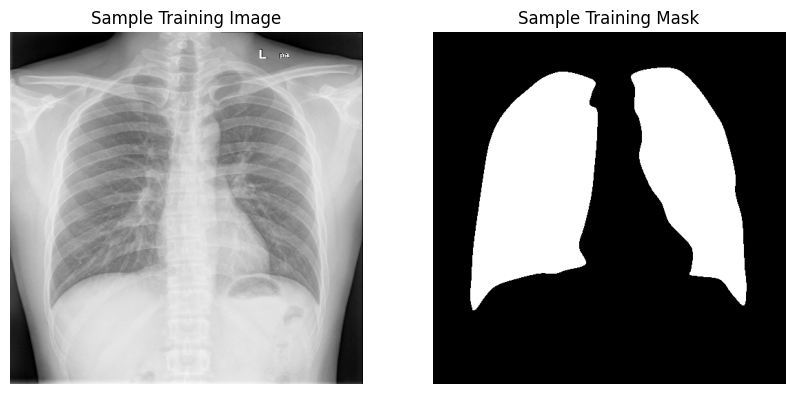

Unique pixel values in one training mask (CHNCXR_0106_0_mask.png): [  0 255]


In [8]:
# Display one random sample from training.
if train_image_count > 0:
    sample_train_image_name = random.choice(os.listdir(TRAIN_IMAGE_DIR))
    sample_train_image_path = os.path.join(TRAIN_IMAGE_DIR, sample_train_image_name)
    filename, ext = os.path.splitext(sample_train_image_name)
    if "_mask" not in sample_train_image_name:
        sample_train_mask_name = f"{filename}_mask{ext}"
    else:
        sample_train_mask_name = sample_train_image_name
    sample_train_mask_path = os.path.join(TRAIN_MASK_DIR, sample_train_mask_name)
    
    sample_train_image = cv2.imread(sample_train_image_path)
    sample_train_mask  = cv2.imread(sample_train_mask_path, cv2.IMREAD_GRAYSCALE)
    
    if sample_train_image is not None and sample_train_mask is not None:
        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        plt.imshow(cv2.cvtColor(sample_train_image, cv2.COLOR_BGR2RGB))
        plt.title("Sample Training Image")
        plt.axis("off")
        plt.subplot(1,2,2)
        plt.imshow(sample_train_mask, cmap="gray")
        plt.title("Sample Training Mask")
        plt.axis("off")
        plt.show()
    else:
        print("Could not load training sample image/mask.")
else:
    print("No training images found.")

# Check unique pixel values in one training mask.
if train_mask_count > 0:
    some_mask_file = os.path.join(TRAIN_MASK_DIR, os.listdir(TRAIN_MASK_DIR)[0])
    some_mask = cv2.imread(some_mask_file, cv2.IMREAD_GRAYSCALE)
    if some_mask is not None:
        unique_vals = np.unique(some_mask)
        print(f"Unique pixel values in one training mask ({os.path.basename(some_mask_file)}):", unique_vals)
    else:
        print("Could not load a training mask for pixel value check.")


In [9]:
img_transform = Compose([
    Resize(IMG_SIZE),
    ToTensor(),  # Converts the PIL image from [0,255] to [0,1] as a tensor.
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

mask_transform = Compose([
    Resize(IMG_SIZE),
    ToTensor()
])

In [10]:
def load_dataset(image_dir, mask_dir):
    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
    images = []
    masks = []
    for f in image_files:
        image_path = os.path.join(image_dir, f)
        # Construct the corresponding mask filename:
        if "_mask" not in f:
            filename, ext = os.path.splitext(f)
            mask_filename = f"{filename}_mask{ext}"
        else:
            mask_filename = f
        mask_path = os.path.join(mask_dir, mask_filename)
        # Load image and mask.
        image = Image.open(image_path).convert("RGB")
        mask  = Image.open(mask_path).convert("L")
        image = img_transform(image)
        mask = mask_transform(mask)
        mask = (mask > 0.5).float()  # Binarize mask.
        images.append(image)
        masks.append(mask)
    images_tensor = torch.stack(images)
    masks_tensor = torch.stack(masks)
    return TensorDataset(images_tensor, masks_tensor)

In [11]:
train_dataset = load_dataset(TRAIN_IMAGE_DIR, TRAIN_MASK_DIR)
val_dataset   = load_dataset(TEST_IMAGE_DIR, TEST_MASK_DIR)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the U-Net model.
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-19c8e357.pth" to /root/.cache/torch/hub/checkpoints/resnet50-19c8e357.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 381MB/s]


In [13]:
# Loss function
loss_fn = smp.losses.DiceLoss(mode='binary')

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Metrics
iou_metric = BinaryJaccardIndex(threshold=0.5).to(device)
accuracy_metric = BinaryAccuracy(threshold=0.5).to(device)
dice_metric = Dice(threshold=0.5).to(device)

In [14]:
# Training hyperparameters.
patience = 5
best_val_loss = float('inf')
epochs_without_improvement = 0
num_epochs = 25

score_history = {
    'epoch': [],
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_accuracy': [],
    'val_dice': []
}

# Training loop.
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)  # Already in [0,1] and shape [B,1,H,W]
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
    avg_train_loss = train_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    # Reset metrics before validation.
    iou_metric.reset()
    accuracy_metric.reset()
    dice_metric.reset()
    
    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            val_loss += loss.item() * images.size(0)
            
            outputs = torch.sigmoid(outputs)
            preds = (outputs > 0.5).float()
            
            # Convert predictions and masks to int
            preds_int = preds.long()
            masks_int = masks.long()
            
            # Update metrics for current batch.
            iou_metric.update(preds_int, masks_int)
            accuracy_metric.update(preds_int, masks_int)
            dice_metric.update(preds_int, masks_int)
    
    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_iou = iou_metric.compute().item()
    avg_acc = accuracy_metric.compute().item()
    avg_dice = dice_metric.compute().item()
    
    # Reset metrics after epoch.
    iou_metric.reset()
    accuracy_metric.reset()
    dice_metric.reset()

    score_history['epoch'].append(epoch + 1)
    score_history['train_loss'].append(avg_train_loss)
    score_history['val_loss'].append(avg_val_loss)
    score_history['val_iou'].append(avg_iou)
    score_history['val_accuracy'].append(avg_acc)
    score_history['val_dice'].append(avg_dice)

    # Early stopping check.
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}, Val IoU: {avg_iou:.4f}, Val Accuracy: {avg_acc:.4f}, Val Dice: {avg_dice:.4f}")

Epoch [1/25]
Train Loss: 0.3033
Val Loss: 0.2353, Val IoU: 0.8937, Val Accuracy: 0.9716, Val Dice: 0.9716
Epoch [2/25]
Train Loss: 0.1986
Val Loss: 0.1873, Val IoU: 0.9025, Val Accuracy: 0.9742, Val Dice: 0.9742
Epoch [3/25]
Train Loss: 0.1574
Val Loss: 0.1534, Val IoU: 0.9168, Val Accuracy: 0.9785, Val Dice: 0.9785
Epoch [4/25]
Train Loss: 0.1294
Val Loss: 0.1282, Val IoU: 0.9120, Val Accuracy: 0.9770, Val Dice: 0.9770
Epoch [5/25]
Train Loss: 0.1058
Val Loss: 0.1102, Val IoU: 0.9197, Val Accuracy: 0.9793, Val Dice: 0.9793
Epoch [6/25]
Train Loss: 0.0897
Val Loss: 0.0970, Val IoU: 0.9174, Val Accuracy: 0.9787, Val Dice: 0.9787
Epoch [7/25]
Train Loss: 0.0771
Val Loss: 0.0864, Val IoU: 0.9194, Val Accuracy: 0.9794, Val Dice: 0.9794
Epoch [8/25]
Train Loss: 0.0647
Val Loss: 0.0771, Val IoU: 0.9223, Val Accuracy: 0.9803, Val Dice: 0.9803
Epoch [9/25]
Train Loss: 0.0571
Val Loss: 0.0718, Val IoU: 0.9211, Val Accuracy: 0.9798, Val Dice: 0.9798
Epoch [10/25]
Train Loss: 0.0506
Val Loss: 0.0

In [15]:
torch.save(model.state_dict(), "/kaggle/working/Lung_Unet_50.pth")

In [16]:
df_scores = pd.DataFrame(score_history)
df_scores.to_csv("/kaggle/working/Lung_Unet_50_Scores.csv", index=False)
print("Training scores saved.")

Training scores saved.
